# Code Walkthrough: Separable Filters and Sharpening

## 1. Images

First, we specify the directory where all the images are located and show the list of images available.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import correlate2d

IMAGES_DIR = Path("./../src-marimo/images")

In [2]:
image_paths = sorted(IMAGES_DIR.glob("*.png"))
print('List of images in the images directory:\n')
for p in image_paths:
    print("  "+p.name)

List of images in the images directory:

  astronaut.png
  chelsea.png
  coffee.png
  raccoon.png


Pick one image by name (edit the string below if you want to select a different image):

In [3]:
image_name = "chelsea"
img_rgb = plt.imread(IMAGES_DIR / f"{image_name}.png")[:, :, :3].astype(np.float64) * 255.0

**TASK:** Diplay the image.

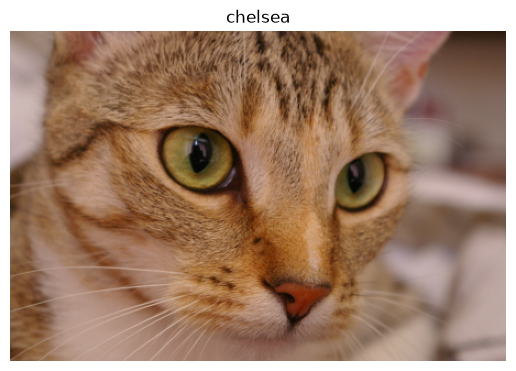

In [4]:
plt.imshow(img_rgb.astype(np.uint8))
plt.axis("off")
plt.title(image_name)
plt.show()

## 2. Separable 2D kernels

**TASK:** Let's start by defining a function that takes as input two different numpy 1D arrays and produces a 2D kernel by applying the outer product.

In [5]:
def outer_product_kernel(kernel_1, kernel_2):
    return np.outer(kernel_1, kernel_2)

### Box filter

**TASK:** Let's obtain a box average filter in 2D by defining a 1D filter and using the function above to generate a 2D filter.

In [7]:
box_size = 5
box_1d = np.ones(box_size) / box_size
box_2d = outer_product_kernel(box_1d, box_1d)

print(box_2d)

[[0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]]


### Gaussian filter

**TASK:** Define a function that takes a 1D kernel and a number of times that the kernel should be convolved, and returns a new 1D kernel resulting of convolving the kernel with itself.

In [8]:
def convolve_kernel_n_times(kernel_1d, n_iter):
    result = kernel_1d.copy()
    for _ in range(n_iter):
        result = np.convolve(result, kernel_1d)
    return result

**TASK:** Plot the kernels resulting on running the previous function with the number of iterations equals to 3, 6 and 12. Make sure that all the plots are centered.

[0.0625 0.25   0.375  0.25   0.0625]
[0.0078125 0.0546875 0.1640625 0.2734375 0.2734375 0.1640625 0.0546875
 0.0078125]
[1.22070312e-04 1.58691406e-03 9.52148438e-03 3.49121094e-02
 8.72802734e-02 1.57104492e-01 2.09472656e-01 2.09472656e-01
 1.57104492e-01 8.72802734e-02 3.49121094e-02 9.52148438e-03
 1.58691406e-03 1.22070312e-04]


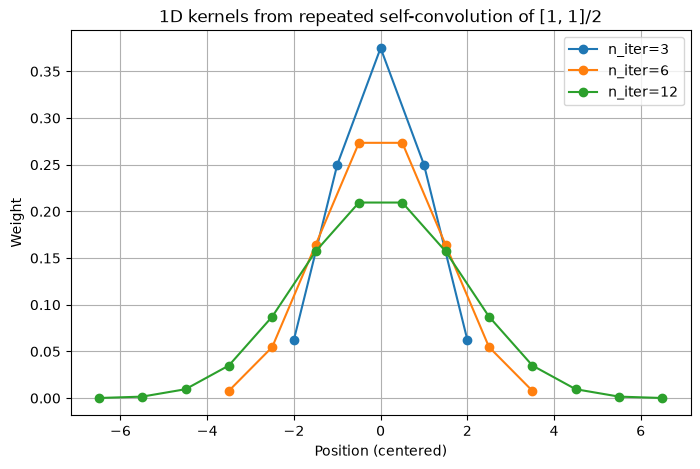

In [11]:
base_kernel = np.array([1, 1]) / 2

plt.figure(figsize=(8, 5))
for n_iter in [3, 6, 12]:
    kernel = convolve_kernel_n_times(base_kernel, n_iter)
    print(kernel)
    x = np.arange(len(kernel)) - (len(kernel) - 1) / 2  # center x-axis at 0
    plt.plot(x, kernel, marker='o', label=f"n_iter={n_iter}")

plt.title("1D kernels from repeated self-convolution of [1, 1]/2")
plt.xlabel("Position (centered)")
plt.ylabel("Weight")
plt.legend()
plt.grid(True)
plt.show()


**TASK:** Now generate a 2D kernel from the 1D kernels resulting from 12 iterations of the smaller 1D kernel.

In [13]:
gaussian_1d = convolve_kernel_n_times(base_kernel, 12)
gaussian_2d = outer_product_kernel(gaussian_1d, gaussian_1d)

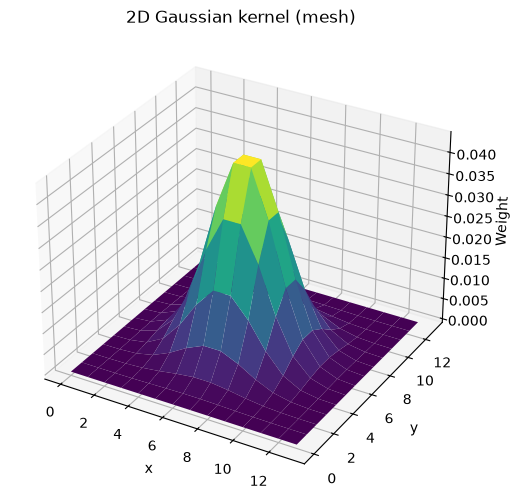

In [16]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (enables 3D projection)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

rows, cols = gaussian_2d.shape
x = np.arange(cols)
y = np.arange(rows)
X, Y = np.meshgrid(x, y)

ax.plot_surface(X, Y, gaussian_2d, cmap="viridis")
ax.set_title("2D Gaussian kernel (mesh)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("Weight")
plt.show()


### Sobel filter

**TASK:** Write a function that converts the color image to a grayscale image.

In [17]:
def to_grayscale(img_rgb):
    weights = np.array([0.2989, 0.5870, 0.1140])  # standard R, G, B luminance weights
    return img_rgb @ weights

**TASK:** Create the Sobel_x filter by performing the outer product of a standard derivative kernel in 1D and the Gaussian kernel in 1D resulting in applying two iterations of the smaller kernel.

In [23]:
derivative_1d = np.array([-1, 0, 1]) / 2
gaussian_small = convolve_kernel_n_times(base_kernel, 1)

sobel_x = outer_product_kernel(gaussian_small, derivative_1d)


**TASK:** Apply the Sobel kernel to the loaded image and display the results.

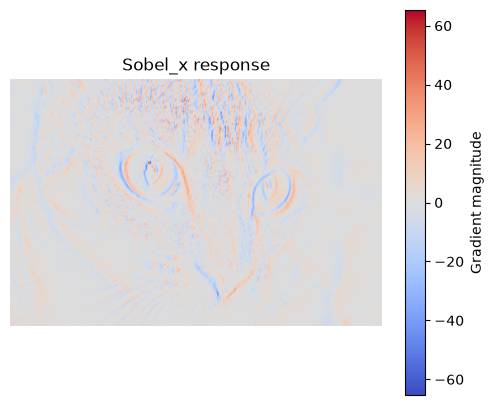

In [28]:
img_gray = to_grayscale(img_rgb)
sobel_response = correlate2d(img_gray, sobel_x, mode='same', boundary='symm')

vmax = np.abs(sobel_response).max()

plt.figure(figsize=(6, 5))
plt.imshow(sobel_response, cmap="coolwarm", vmin=-vmax, vmax=vmax)
plt.title("Sobel_x response")
plt.axis("off")
plt.colorbar(label="Gradient magnitude")
plt.show()

## 3. Sharpening

**TASK:** Define a function that applies the same 2D kernel to each channel of a color image.


**TASK:** Use the previous function to implement the sharpening operation and apply it to our color image.

$f_\text{sharp} = f + \gamma\,(f - h_\text{blur} * f)$

**TASK:** Display a figure that illustrates the original color image, the result of just bluring, and the sharpened image side by side.